# Workload Query & Generation-Overhead Analysis

A deeper companion to `tpcds_generator_analysis.ipynb`. That notebook answers
*"is the workload diverse and valid?"*. This one ignores fidelity entirely and
instead looks at **two things the summary tables gloss over**:

1. **The queries themselves** — the shape of the generated SQL: how many tables,
   joins, predicates, sub-queries, CTEs, window functions, etc. each query
   carries, and how that distribution differs across generators.
2. **Generation overhead** — what it *cost* to produce each workload: wall-clock
   generation time, throughput (queries/min), and — for our generator — how many
   candidate queries had to be generated and rejected per accepted query.

**Data sources.** Query-shape distributions come from the diversity CSV(s)
(`meta_num_*` columns, computed identically for every workload). Overhead comes
straight from each workload's `generation_report.json` ("generation logs"), which
also feeds the new `gen_*` columns added to `analysis.py`. Everything here runs
offline — no live Trino connection needed.

In [10]:
import os, json
from pathlib import Path
import pandas as pd, numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 300, "savefig.bbox": "tight",
    "font.size": 9, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.5,
})

# --- one or more diversity CSVs (query-shape metrics), newest last ----------
CSVS = [
    "results/tpcds_baseline_diversity_comparison_1000.csv",
    "results/tpcds_baseline_diversity_comparison_1000_v3.csv",
]
REF = "tpcds"          # hand-crafted reference (no generation cost)

# --- where to find each workload's generation_report.json -------------------
# Searched in order; the first hit wins. Add your own mount if needed.
WORKLOAD_ROOTS = [
    Path("../../Workloads"),               # local repo copy (this machine)
    Path("/mnt/primary/Main/Workloads"),   # remote mount
]

# --- load + merge the CSV rows ----------------------------------------------
frames = []
for path in CSVS:
    f = pd.read_csv(path)
    f["source_file"] = os.path.basename(path)
    frames.append(f)
df = pd.concat(frames, ignore_index=True)
df = df.drop_duplicates(subset="workload", keep="last").set_index("workload")

OURS      = [w for w in df.index if "gpt_generated" in w and w != REF]
GENS      = [w for w in df.index if w != REF]
BASELINES = [w for w in GENS if w not in OURS]
ORDER     = OURS + BASELINES               # generators, ours first
ROWS      = [REF] + ORDER                   # reference on top

_ours_palette = ["#c2410c", "#ea580c", "#f97316", "#fb923c"]
COL = {w: "#b8b8b8" for w in df.index}
for i, w in enumerate(OURS):
    COL[w] = _ours_palette[i % len(_ours_palette)]
COL[REF] = "#111111"

def show(tbl, fmt=None):
    """Reference row greyed/italic; our workloads highlighted warm."""
    def hl(row):
        if row.name == REF:
            return ["background-color:#f3f4f6;font-style:italic"] * len(row)
        if row.name in OURS:
            return ["background-color:#fff1e6;font-weight:600"] * len(row)
        return [""] * len(row)
    sty = tbl.style.apply(hl, axis=1)
    return sty.format(fmt) if fmt else sty

print(f"{len(df)} workloads | ours={OURS} | baselines={BASELINES}")
df["source_file"]

8 workloads | ours=['gpt_generated_tpcds', 'gpt_generated_1000_tpcds_v3'] | baselines=['bootstrapping_lcm_1000_tpcds', 'e2etune_1000_tpcds', 'sql_factory_1000_tpcds', 'sqlbarber_1000_tpcds', 'sqlstorm_1000_tpcds']


workload
tpcds                              tpcds_baseline_diversity_comparison_1000.csv
bootstrapping_lcm_1000_tpcds       tpcds_baseline_diversity_comparison_1000.csv
e2etune_1000_tpcds                 tpcds_baseline_diversity_comparison_1000.csv
gpt_generated_tpcds                tpcds_baseline_diversity_comparison_1000.csv
sql_factory_1000_tpcds             tpcds_baseline_diversity_comparison_1000.csv
sqlbarber_1000_tpcds               tpcds_baseline_diversity_comparison_1000.csv
sqlstorm_1000_tpcds                tpcds_baseline_diversity_comparison_1000.csv
gpt_generated_1000_tpcds_v3     tpcds_baseline_diversity_comparison_1000_v3.csv
Name: source_file, dtype: object

## Load the generation logs

Read each workload's `generation_report.json` for the overhead figures and (for
our generator) the design-mix breakdowns. Mirrors `analysis.load_generation_overhead`
but stays dependency-free so the notebook runs anywhere.

In [11]:
def find_report(workload):
    for root in WORKLOAD_ROOTS:
        p = Path(root) / workload / "generation_report.json"
        if p.exists():
            with p.open(encoding="utf-8") as fh:
                return json.load(fh)
    return None

reports = {w: r for w in df.index if (r := find_report(w)) is not None}

def overhead_row(rep):
    model = rep.get("model") or {}
    par   = rep.get("parallelism") or {}
    val   = rep.get("validation") or {}
    nq, dur = rep.get("num_queries"), rep.get("duration_s")
    row = {
        "generator":   rep.get("generator") or rep.get("baseline"),
        "queries":     nq,
        "duration_s":  dur,
        "duration_min": (dur / 60.0) if dur else np.nan,
        "queries_per_min":   (nq / (dur / 60.0)) if (dur and nq) else np.nan,
        "seconds_per_query": (dur / nq) if (dur and nq) else np.nan,
        "workers":     par.get("generation_workers"),
        "reasoning":   rep.get("reasoning") or model.get("reasoning"),
        "candidates":  val.get("total_candidates_generated"),
        "rejected":    val.get("num_invalid_queries_rejected"),
    }
    if row["candidates"]:
        row["rejection_rate"]      = (row["rejected"] or 0) / row["candidates"]
        row["candidates_per_query"] = row["candidates"] / nq if nq else np.nan
    else:
        row["rejection_rate"] = row["candidates_per_query"] = np.nan
    return row

overhead = pd.DataFrame({w: overhead_row(r) for w, r in reports.items()}).T
overhead = overhead.reindex([w for w in ORDER if w in overhead.index])
missing = [w for w in ORDER if w not in overhead.index]
if missing:
    print("no generation_report.json for:", missing)
print(f"overhead loaded for {len(overhead)} generators")
overhead[["generator", "queries", "duration_min", "queries_per_min",
          "seconds_per_query", "workers", "reasoning"]]

overhead loaded for 7 generators


,generator,queries,duration_min,queries_per_min,seconds_per_query,workers,reasoning
gpt_generated_tpcds,None,1000,118.384191,8.447074,7.103051,64,high
gpt_generated_1000_tpcds_v3,query_generator_v3,1000,426.72844,2.343411,25.603706,32,high
bootstrapping_lcm_1000_tpcds,bootstrapping_lcm,1000,252.032431,3.967743,15.121946,None,high
e2etune_1000_tpcds,e2etune,1000,154.261706,6.48249,9.255702,None,high
sql_factory_1000_tpcds,sql_factory,139,29.828008,4.66005,12.875399,None,high
sqlbarber_1000_tpcds,sqlbarber,1000,94.010953,10.637058,5.640657,None,high
sqlstorm_1000_tpcds,sqlstorm,1000,621.579919,1.608804,37.294795,None,high


## 1 · Generation overhead  (workbook §5)

Wall-clock cost of producing each workload. `tpcds` is hand-crafted, so it has no
generation cost and is absent here. Lower time / higher throughput is better.

In [12]:
ov = overhead.copy()
ov_tbl = ov[["queries", "duration_min", "queries_per_min", "seconds_per_query",
             "workers", "candidates", "rejection_rate"]].astype(float)
show(ov_tbl).format({
    "queries": "{:.0f}", "duration_min": "{:.1f}", "queries_per_min": "{:.2f}",
    "seconds_per_query": "{:.1f}", "workers": "{:.0f}",
    "candidates": "{:.0f}", "rejection_rate": "{:.1%}",
})

,queries,duration_min,queries_per_min,seconds_per_query,workers,candidates,rejection_rate
gpt_generated_tpcds,1000,118.4,8.45,7.1,64,1016,1.6%
gpt_generated_1000_tpcds_v3,1000,426.7,2.34,25.6,32,1000,0.0%
bootstrapping_lcm_1000_tpcds,1000,252.0,3.97,15.1,nan,nan,nan%
e2etune_1000_tpcds,1000,154.3,6.48,9.3,nan,nan,nan%
sql_factory_1000_tpcds,139,29.8,4.66,12.9,nan,nan,nan%
sqlbarber_1000_tpcds,1000,94.0,10.64,5.6,nan,nan,nan%
sqlstorm_1000_tpcds,1000,621.6,1.61,37.3,nan,nan,nan%


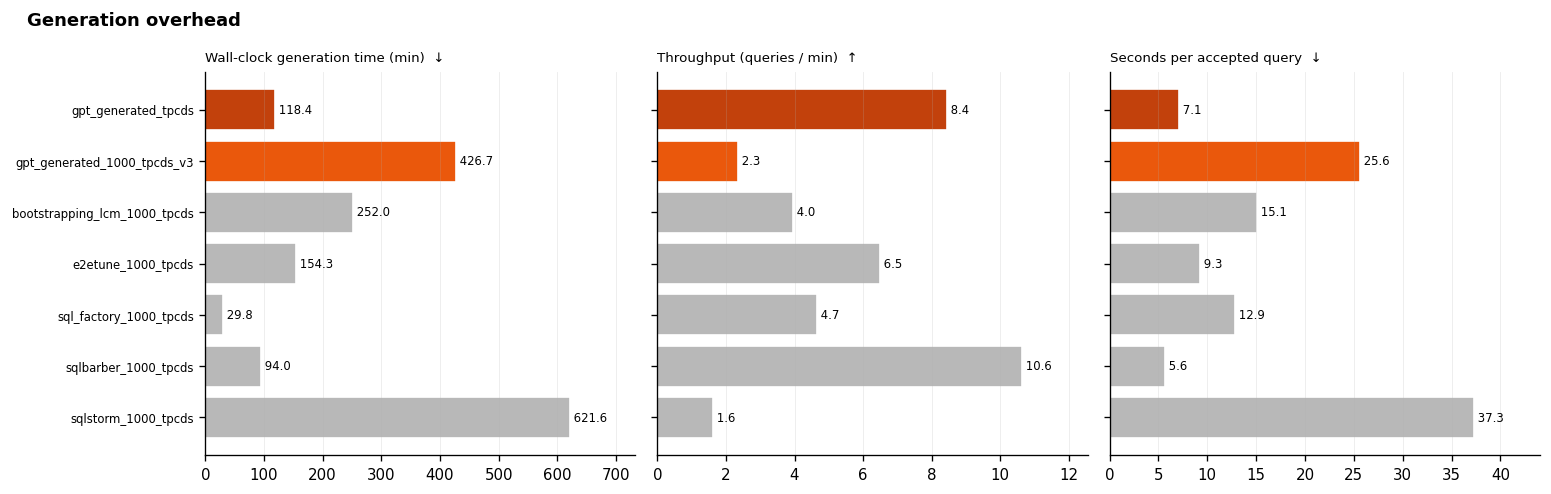

In [13]:
gens = list(ov.index)
fig, axes = plt.subplots(1, 3, figsize=(13, 0.42 * len(gens) + 1.2))
panels = [
    ("duration_min",      "Wall-clock generation time (min)  ↓"),
    ("queries_per_min",   "Throughput (queries / min)  ↑"),
    ("seconds_per_query", "Seconds per accepted query  ↓"),
]
for ax, (col, title) in zip(axes, panels):
    vals = ov[col].astype(float)
    ax.barh(range(len(gens)), vals.values,
            color=[COL[w] for w in gens], edgecolor="white")
    for i, v in enumerate(vals.values):
        ax.text(v, i, f" {v:,.1f}", va="center", fontsize=7)
    ax.set_yticks(range(len(gens)))
    ax.set_yticklabels(gens if ax is axes[0] else [], fontsize=7)
    ax.invert_yaxis(); ax.set_title(title, fontsize=8, loc="left")
    ax.grid(axis="y", visible=False); ax.margins(x=0.18)
fig.suptitle("Generation overhead", x=0.02, ha="left", fontweight="bold")
plt.tight_layout(); plt.show()

### Candidate efficiency (our generator)

Our generator validates every candidate with `EXPLAIN` and rejects invalid ones,
so it generates more candidates than it keeps. Grey = accepted (written); orange
= rejected. A short orange stub means grounding rarely produces invalid SQL.

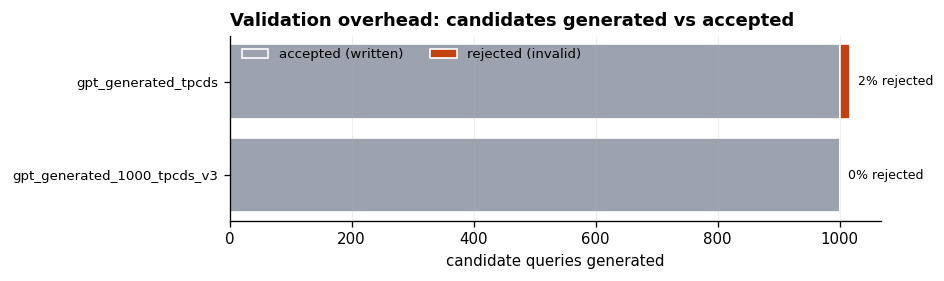

In [14]:
cand = ov[ov["candidates"].notna()]
if cand.empty:
    print("No candidate/validation data recorded for any loaded workload.")
else:
    fig, ax = plt.subplots(figsize=(7, 0.5 * len(cand) + 1))
    y = range(len(cand))
    accepted = cand["queries"].astype(float).values
    rejected = (cand["candidates"] - cand["queries"]).astype(float).values
    ax.barh(y, accepted, color="#9ca3af", edgecolor="white", label="accepted (written)")
    ax.barh(y, rejected, left=accepted, color="#c2410c", edgecolor="white",
            label="rejected (invalid)")
    for i, (a, r) in enumerate(zip(accepted, rejected)):
        ax.text(a + r, i, f"  {r/ (a+r):.0%} rejected", va="center", fontsize=7.5)
    ax.set_yticks(list(y)); ax.set_yticklabels(list(cand.index), fontsize=8)
    ax.invert_yaxis(); ax.set_xlabel("candidate queries generated")
    ax.set_title("Validation overhead: candidates generated vs accepted",
                 loc="left", fontweight="bold")
    ax.legend(frameon=False, fontsize=8, ncol=2); ax.grid(axis="y", visible=False)
    plt.show()

## 2 · The queries themselves — structural profile

How complex are the generated queries? Each panel is one SQL feature; the bar
spans the workload's **min–max** range, the vertical tick marks the **mean** and
the dot marks the **median**. The dashed line is the real TPC-DS mean. This is
the query-shape view: are the queries trivial single-scans or deep multi-join
analytics, and how wide is the spread?

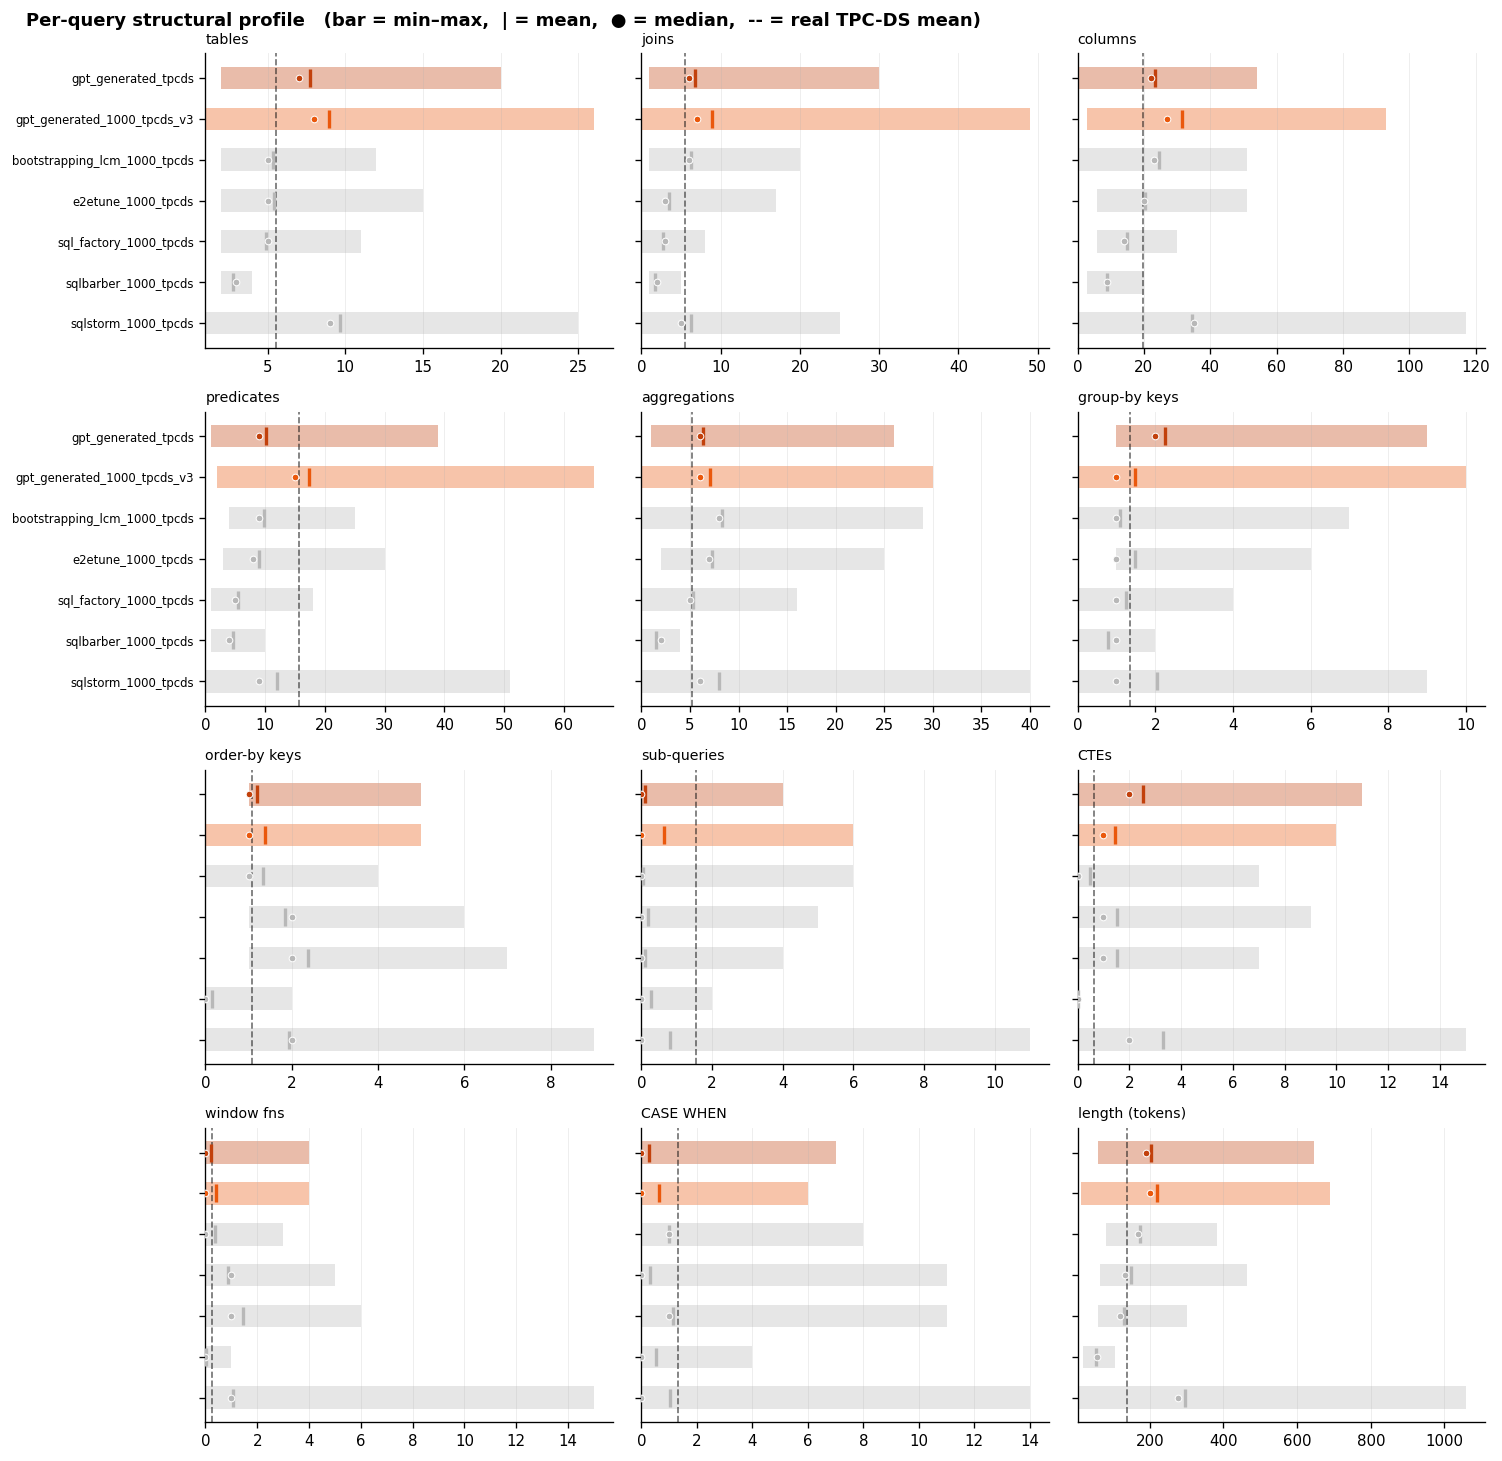

In [15]:
FEATURES = {
    "num_tables":           "tables",
    "num_joins":            "joins",
    "num_columns":          "columns",
    "num_predicates":       "predicates",
    "num_aggregations":     "aggregations",
    "num_group_by":         "group-by keys",
    "num_order_by":         "order-by keys",
    "num_subqueries":       "sub-queries",
    "num_ctes":             "CTEs",
    "num_window_functions": "window fns",
    "num_case_when":        "CASE WHEN",
    "query_length_tokens":  "length (tokens)",
}

def feat(w, f, stat):
    return float(df.loc[w, f"meta_{f}_{stat}"])

ncols = 3
nrows = int(np.ceil(len(FEATURES) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 0.42 * len(ORDER) * nrows + 0.6))
axes = np.atleast_1d(axes).ravel()
for ax, (f, label) in zip(axes, FEATURES.items()):
    for i, w in enumerate(ORDER):
        lo, hi = feat(w, f, "min"), feat(w, f, "max")
        ax.barh(i, max(hi - lo, 1e-9), left=lo, height=0.55,
                color=COL[w], alpha=0.35, zorder=1)
        ax.plot([feat(w, f, "mean")], [i], "|", color=COL[w], ms=11, mew=2, zorder=3)
        ax.plot([feat(w, f, "median")], [i], "o", color=COL[w], ms=4,
                mec="white", mew=0.6, zorder=3)
    if REF in df.index:
        ax.axvline(feat(REF, f, "mean"), color="#111", ls="--", lw=1, alpha=.6, zorder=2)
    ax.set_yticks(range(len(ORDER)))
    ax.set_yticklabels(ORDER if ax in (axes[0], axes[ncols]) else [], fontsize=7)
    ax.invert_yaxis(); ax.set_title(label, fontsize=8.5, loc="left")
    ax.grid(axis="y", visible=False)
for ax in axes[len(FEATURES):]:
    ax.axis("off")
fig.suptitle("Per-query structural profile   "
             "(bar = min–max,  | = mean,  ● = median,  -- = real TPC-DS mean)",
             x=0.02, ha="left", fontweight="bold")
plt.tight_layout(); plt.show()

### Complexity mix

Each generator's split of low / medium / high-complexity queries (from the static
SQL feature extractor). A healthy analytical workload leans medium/high.

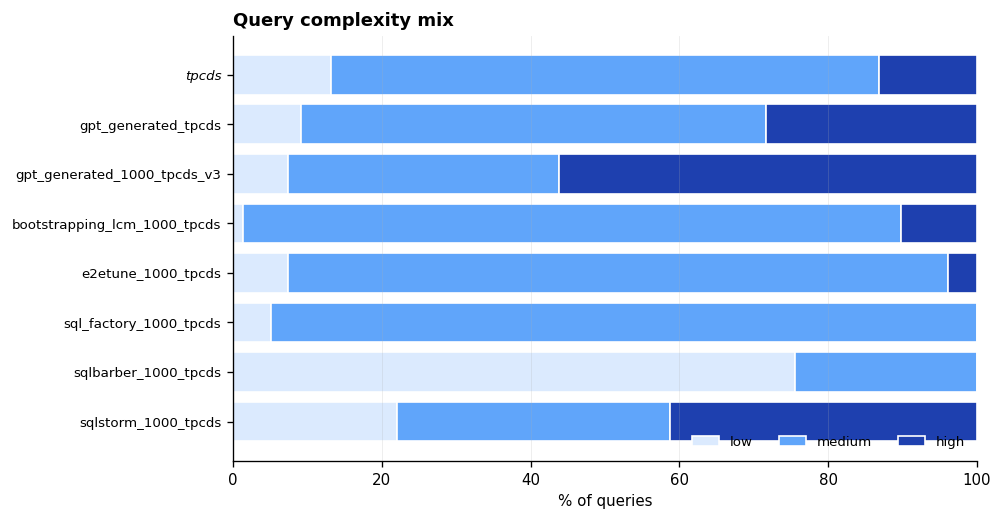

,low,medium,high
workload,,,
tpcds,13.1,73.7,13.1
gpt_generated_tpcds,9.1,62.6,28.3
gpt_generated_1000_tpcds_v3,7.4,36.4,56.2
bootstrapping_lcm_1000_tpcds,1.4,88.4,10.2
e2etune_1000_tpcds,7.4,88.7,3.9
sql_factory_1000_tpcds,5.0,95.0,0.0
sqlbarber_1000_tpcds,75.5,24.5,0.0
sqlstorm_1000_tpcds,22.0,36.7,41.3


In [16]:
mix_cols = ["meta_complexity_low_pct", "meta_complexity_medium_pct", "meta_complexity_high_pct"]
mix = df.loc[ROWS, mix_cols].astype(float)
mix.columns = ["low", "medium", "high"]

fig, ax = plt.subplots(figsize=(8, 0.45 * len(ROWS) + 1))
shades = ["#dbeafe", "#60a5fa", "#1e40af"]
left = np.zeros(len(ROWS))
for c, sh in zip(mix.columns, shades):
    ax.barh(range(len(ROWS)), mix[c].values, left=left, color=sh,
            edgecolor="white", label=c)
    left += mix[c].values
ax.set_yticks(range(len(ROWS))); ax.set_yticklabels(ROWS, fontsize=8)
ax.get_yticklabels()[0].set_fontstyle("italic")
ax.invert_yaxis(); ax.set_xlabel("% of queries")
ax.legend(frameon=False, ncol=3, fontsize=8, loc="lower right")
ax.set_title("Query complexity mix", loc="left", fontweight="bold")
ax.grid(axis="y", visible=False)
plt.show()

show(mix, "{:.1f}")

### Query-shape summary table (means)

The mean of every structural feature, side by side — the numeric backbone of the
profile plot above.

In [17]:
prof = pd.DataFrame(
    {label: [feat(w, f, "mean") for w in ROWS] for f, label in FEATURES.items()},
    index=ROWS,
)
show(prof, "{:.1f}")

,tables,joins,columns,predicates,aggregations,group-by keys,order-by keys,sub-queries,CTEs,window fns,CASE WHEN,length (tokens)
tpcds,5.6,5.5,19.8,15.7,5.2,1.4,1.1,1.5,0.6,0.3,1.3,137.4
gpt_generated_tpcds,7.7,6.7,23.2,10.2,6.3,2.2,1.2,0.1,2.5,0.2,0.3,204.4
gpt_generated_1000_tpcds_v3,9.0,8.9,31.5,17.4,7.0,1.5,1.4,0.6,1.5,0.4,0.6,219.6
bootstrapping_lcm_1000_tpcds,5.4,6.3,24.4,9.8,8.3,1.1,1.3,0.1,0.5,0.4,1.0,172.8
e2etune_1000_tpcds,5.4,3.5,20.3,8.9,7.3,1.5,1.9,0.2,1.5,0.9,0.3,149.1
sql_factory_1000_tpcds,4.9,2.8,15.0,5.5,5.3,1.2,2.4,0.1,1.5,1.4,1.1,130.1
sqlbarber_1000_tpcds,2.8,1.8,8.9,4.6,1.5,0.8,0.2,0.3,0.0,0.0,0.5,55.1
sqlstorm_1000_tpcds,9.7,6.3,34.5,11.9,8.0,2.1,1.9,0.8,3.3,1.1,1.0,295.2


## 3 · Generator design mix  (our generator)

What the generator actually asked for, per query: the mix of prompt families,
optional shape add-ons (CTE / sub-query / window / …) and table-sampling modes.
Only shown for workloads whose report records `diversity_mechanisms` (our v2+
generator).

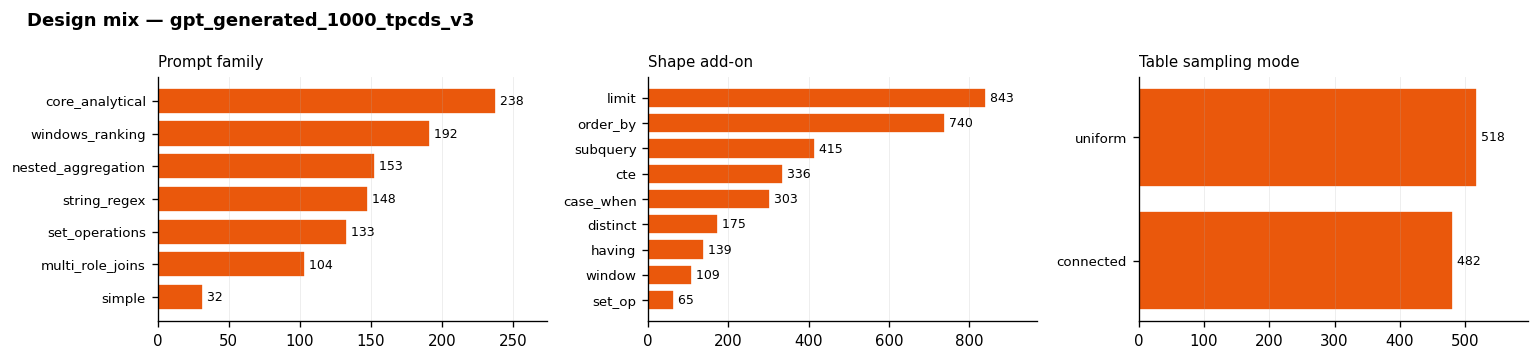

In [18]:
def mix_of(rep, key):
    m = (rep.get("diversity_mechanisms") or {}).get(key)
    return pd.Series(m) if m else None

mix_specs = [
    ("prompt_variant_mix", "Prompt family"),
    ("shape_addon_mix",    "Shape add-on"),
    ("sampling_mode_mix",  "Table sampling mode"),
]
targets = [w for w in OURS if w in reports and reports[w].get("diversity_mechanisms")]

if not targets:
    print("No diversity_mechanisms recorded in any 'ours' report.")
for w in targets:
    rep = reports[w]
    panels = [(k, t, mix_of(rep, k)) for k, t in mix_specs]
    panels = [(k, t, s) for k, t, s in panels if s is not None]
    fig, axes = plt.subplots(1, len(panels), figsize=(4.3 * len(panels), 3))
    axes = np.atleast_1d(axes).ravel()
    for ax, (k, t, s) in zip(axes, panels):
        s = s.sort_values()
        ax.barh(range(len(s)), s.values, color=COL[w], edgecolor="white")
        for i, v in enumerate(s.values):
            ax.text(v, i, f" {int(v)}", va="center", fontsize=7.5)
        ax.set_yticks(range(len(s))); ax.set_yticklabels(s.index, fontsize=8)
        ax.set_title(t, fontsize=9, loc="left"); ax.grid(axis="y", visible=False)
        ax.margins(x=0.15)
    fig.suptitle(f"Design mix — {w}", x=0.02, ha="left", fontweight="bold")
    plt.tight_layout(); plt.show()